In [1]:
import umap 
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import trustworthiness, TSNE
from metrics import pairwise_distance_correlation, knn_accuracy, knn_recall
from sklearn.metrics import silhouette_score

from IsUMap import IsUMap

import time

**Загрузка данных**

In [2]:
adata = sc.read_h5ad('GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
print(adata)
print(adata.X.shape)

AnnData object with n_obs × n_vars = 90261 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'
(90261, 14087)


In [4]:
adata.obs

,GEX_n_genes_by_counts,GEX_pct_counts_mt,GEX_size_factors,GEX_phase,ADT_n_antibodies_by_counts,ADT_total_counts,ADT_iso_count,cell_type,batch,ADT_pseudotime_order,...,DonorID,DonorAge,DonorBMI,DonorBloodType,DonorRace,Ethnicity,DonorGender,QCMeds,DonorSmoker,is_train
GCATTAGCATAAGCGG-1-s1d1,893,6.723979,0.356535,G1,115,2828.0,5.0,Naive CD20+ B IGKC+,s1d1,NaN,...,15078,34,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,train
TACAGGTGTTAGAGTA-1-s1d1,2606,8.008829,1.292643,S,137,8819.0,21.0,CD14+ Mono,s1d1,NaN,...,15078,34,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,train
AGGATCTAGGTCTACT-1-s1d1,1867,6.959707,0.970558,G2M,116,4088.0,12.0,Naive CD20+ B IGKC+,s1d1,NaN,...,15078,34,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,train
GTAGAAAGTGACACAG-1-s1d1,2360,6.109234,1.232604,G2M,124,4447.0,9.0,HSC,s1d1,NaN,...,15078,34,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,train
TCCGAAAAGGATCATA-1-s1d1,455,0.294394,0.044585,S,132,12875.0,24.0,Reticulocyte,s1d1,0.735261,...,15078,34,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GAATCACCACGGAAGT-1-s4d9,2115,4.367301,0.916475,G2M,123,3283.0,10.0,Lymph prog,s4d9,NaN,...,13272,35,31.0,O+,Other Race,HISPANIC OR LATINO,Male,False,Nonsmoker,iid_holdout
GCTGGGTGTACGGATG-1-s4d9,1484,4.974369,0.508755,S,124,2695.0,14.0,CD8+ T naive,s4d9,NaN,...,13272,35,31.0,O+,Other Race,HISPANIC OR LATINO,Male,False,Nonsmoker,test
TCGAAGTGTGACAGGT-1-s4d9,801,8.842443,0.232119,G1,132,3590.0,14.0,T reg,s4d9,NaN,...,13272,35,31.0,O+,Other Race,HISPANIC OR LATINO,Male,False,Nonsmoker,test
GCAGGCTGTTGCATAC-1-s4d9,1630,8.500611,0.549119,G1,133,5432.0,17.0,CD4+ T naive,s4d9,NaN,...,13272,35,31.0,O+,Other Race,HISPANIC OR LATINO,Male,False,Nonsmoker,test


In [5]:
adata.var

,feature_types,gene_id
AL627309.5,GEX,ENSG00000241860
LINC01409,GEX,ENSG00000237491
LINC01128,GEX,ENSG00000228794
LINC00115,GEX,ENSG00000225880
FAM41C,GEX,ENSG00000230368
...,...,...
HLA-E,ADT,ENSG00000204592
CD82,ADT,ENSG00000085117
CD101,ADT,ENSG00000134256
CD88,ADT,NaN


In [6]:
n_samples = 3

In [7]:
n = 5000
rng = np.random.default_rng(42)

X_list = []
labels_list = []
for i in range(n_samples):
    idx = rng.choice(adata.n_obs, size=n, replace=False)
    X = adata.obsm['GEX_X_pca'][idx, :50]
    labels = adata.obs['cell_type'].astype(str).to_numpy()[idx]

    X_list.append(X)
    labels_list.append(labels)

In [8]:
n_neighbors_list = [10, 30, 50, 100]
n_runs = 5
seeds = [42 + i for i in range(n_runs)]


**Применение UMAP**

In [9]:
X_umap_list = []
umap_times = []
for el in n_neighbors_list:
    X_umap_runs = []
    umap_time_runs = []
    for seed in seeds:
        X_umap_temp_list = []
        umap_time_temp_list = []
        for i in range(n_samples):
            start = time.perf_counter()
            reducer = umap.UMAP(
                n_neighbors=el,
                metric='euclidean',
                random_state=seed,
            )
            X_umap = reducer.fit_transform(X_list[i])
            end = time.perf_counter()

            umap_time_temp_list.append(end - start)
            X_umap_temp_list.append(X_umap)

        umap_time_runs.append(umap_time_temp_list)
        X_umap_runs.append(X_umap_temp_list)

    umap_times.append(umap_time_runs)
    X_umap_list.append(X_umap_runs)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no 

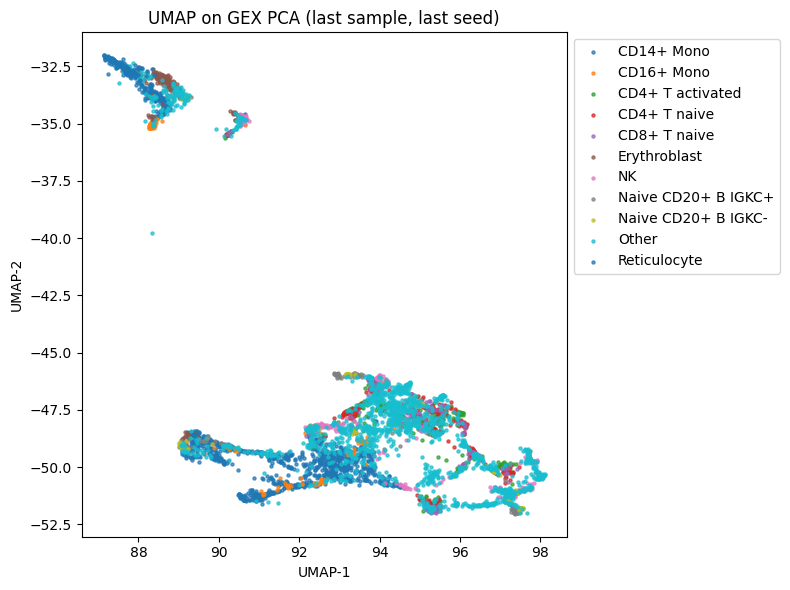

In [10]:
plt.figure(figsize=(8,6))
uniq, cnt = np.unique(labels, return_counts=True)
top = set(uniq[np.argsort(-cnt)[:10]])
labels2 = np.array([l if l in top else 'Other' for l in labels], dtype=object)

for lab in np.unique(labels2):
    m = (labels2 == lab)
    plt.scatter(X_umap_list[-1][-1][-1][m,0], X_umap_list[-1][-1][-1][m,1], s=5, alpha=0.7, label=lab)

plt.title('UMAP on GEX PCA (last sample, last seed)')
plt.xlabel('UMAP-1'); plt.ylabel('UMAP-2')
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.tight_layout()
plt.show()


**Применение IsUMap**

In [11]:
X_isumap_list = []
isumap_times = []
for el in n_neighbors_list:
    X_isumap_runs = []
    isumap_time_runs = []
    for seed in seeds:
        X_isumap_temp_list = []
        isumap_time_temp_list = []
        for i in range(n_samples):
            try:
                start = time.perf_counter()
                isumap = IsUMap(
                    n_neighbors=el,
                    n_components=2,
                    metric='euclidean',
                    mode='um',
                    use_rho=True,
                    random_state=seed,
                )

                X_isumap = isumap.fit_transform(X_list[i])
                end = time.perf_counter()

                isumap_time_temp_list.append(end - start)
                X_isumap_temp_list.append(X_isumap)
            except ValueError:
                print('IsUMap error')
                isumap_time_temp_list.append(0)
                X_isumap_temp_list.append(np.array([]))

        isumap_time_runs.append(isumap_time_temp_list)
        X_isumap_runs.append(X_isumap_temp_list)

    isumap_times.append(isumap_time_runs)
    X_isumap_list.append(X_isumap_runs)


IsUMap error
IsUMap error
IsUMap error
IsUMap error
IsUMap error


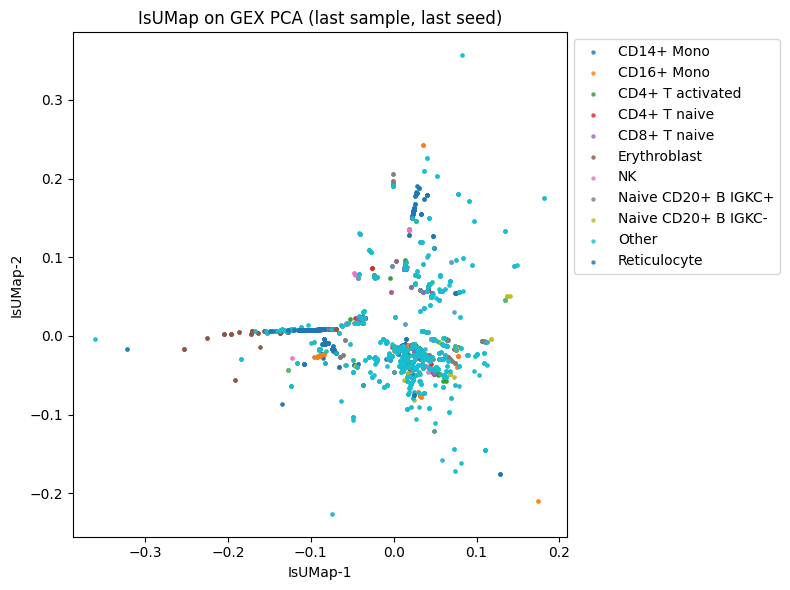

In [12]:
plt.figure(figsize=(8,6))
uniq, cnt = np.unique(labels, return_counts=True)
top = set(uniq[np.argsort(-cnt)[:10]])
labels2 = np.array([l if l in top else 'Other' for l in labels], dtype=object)

for lab in np.unique(labels2):
    m = (labels2 == lab)
    plt.scatter(X_isumap_list[-1][-1][-1][m,0], X_isumap_list[-1][-1][-1][m,1], s=5, alpha=0.7, label=lab)

plt.title('IsUMap on GEX PCA (last sample, last seed)')
plt.xlabel('IsUMap-1'); plt.ylabel('IsUMap-2')
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.tight_layout()
plt.show()


**Сравнение**

In [13]:
# Time
for i in range(len(n_neighbors_list)):
    print(f'n_neighbors = {n_neighbors_list[i]}')

    umap_run_means = [np.mean(umap_times[i][run_idx]) for run_idx in range(n_runs)]
    isumap_run_means = []
    for run_idx in range(n_runs):
        valid_times = [t for t in isumap_times[i][run_idx] if t != 0]
        if valid_times:
            isumap_run_means.append(np.mean(valid_times))

    print(f'UMAP time: {np.mean(umap_run_means):.6f} +- {np.std(umap_run_means):.6f}')
    print(f'IsUMap time: {np.mean(isumap_run_means):.6f} +- {np.std(isumap_run_means):.6f}')
    print()


n_neighbors = 10
UMAP time: 3.861821 +- 0.785689
IsUMap time: 18.646556 +- 0.025964

n_neighbors = 30
UMAP time: 8.533481 +- 0.056355
IsUMap time: 37.589969 +- 0.071141

n_neighbors = 50
UMAP time: 13.772650 +- 0.090775
IsUMap time: 60.704967 +- 0.979645

n_neighbors = 100
UMAP time: 27.082173 +- 0.092421
IsUMap time: 129.570241 +- 0.166359



In [14]:
# Trustworthiness
for i in range(len(n_neighbors_list)):
    print(f'n_neighbors = {n_neighbors_list[i]}')

    tw_umap_runs = []
    tw_isumap_runs = []
    for run_idx in range(n_runs):
        tw_umap_runs.append(np.mean([trustworthiness(X_list[j], X_umap_list[i][run_idx][j], n_neighbors=10, metric='euclidean') for j in range(n_samples)]))

        valid_values = [trustworthiness(X_list[j], X_isumap_list[i][run_idx][j], n_neighbors=10, metric='euclidean') for j in range(n_samples) if X_isumap_list[i][run_idx][j].size > 0]
        if valid_values:
            tw_isumap_runs.append(np.mean(valid_values))

    print(f'UMAP trustworthiness: {np.mean(tw_umap_runs):.6f} +- {np.std(tw_umap_runs):.6f}')
    print(f'IsUMap trustworthiness: {np.mean(tw_isumap_runs):.6f} +- {np.std(tw_isumap_runs):.6f}')
    print()


n_neighbors = 10
UMAP trustworthiness: 0.985714 +- 0.000231
IsUMap trustworthiness: 0.931891 +- 0.000000

n_neighbors = 30
UMAP trustworthiness: 0.973521 +- 0.000450
IsUMap trustworthiness: 0.930886 +- 0.000000

n_neighbors = 50
UMAP trustworthiness: 0.962723 +- 0.000428
IsUMap trustworthiness: 0.931464 +- 0.000000

n_neighbors = 100
UMAP trustworthiness: 0.945279 +- 0.000452
IsUMap trustworthiness: 0.928423 +- 0.000000



In [15]:
# pairwise_distance_correlation
for i in range(len(n_neighbors_list)):
    print(f'n_neighbors = {n_neighbors_list[i]}')

    sp_corr_umap_runs = []
    sp_corr_isumap_runs = []
    for run_idx in range(n_runs):
        sp_corr_umap_runs.append(np.mean([pairwise_distance_correlation(X_list[j], X_umap_list[i][run_idx][j], method='spearman')[0] for j in range(n_samples)]))

        valid_values = [pairwise_distance_correlation(X_list[j], X_isumap_list[i][run_idx][j], method='spearman')[0] for j in range(n_samples) if X_isumap_list[i][run_idx][j].size > 0]
        if valid_values:
            sp_corr_isumap_runs.append(np.mean(valid_values))

    print(f'UMAP spearman corr: {np.mean(sp_corr_umap_runs):.6f} +- {np.std(sp_corr_umap_runs):.6f}')
    print(f'IsUMap spearman corr: {np.mean(sp_corr_isumap_runs):.6f} +- {np.std(sp_corr_isumap_runs):.6f}')
    print()


n_neighbors = 10
UMAP spearman corr: 0.529726 +- 0.019490
IsUMap spearman corr: 0.550170 +- 0.000000

n_neighbors = 30
UMAP spearman corr: 0.417264 +- 0.019324
IsUMap spearman corr: 0.619183 +- 0.000000

n_neighbors = 50
UMAP spearman corr: 0.571479 +- 0.031790
IsUMap spearman corr: 0.622975 +- 0.000000

n_neighbors = 100
UMAP spearman corr: 0.636381 +- 0.008967
IsUMap spearman corr: 0.627341 +- 0.000000



In [16]:
# knn-accuracy
for i in range(len(n_neighbors_list)):
    print(f'n_neighbors = {n_neighbors_list[i]}')

    acc_umap_runs = []
    acc_isumap_runs = []
    for run_idx in range(n_runs):
        acc_umap_runs.append(np.mean([knn_accuracy(X_umap_list[i][run_idx][j], labels_list[j], n_neighbors=10, cv=2)[0] for j in range(n_samples)]))

        valid_values = [knn_accuracy(X_isumap_list[i][run_idx][j], labels_list[j], n_neighbors=10, cv=5)[0] for j in range(n_samples) if X_isumap_list[i][run_idx][j].size > 0]
        if valid_values:
            acc_isumap_runs.append(np.mean(valid_values))

    print(f'UMAP kNN accuracy: {np.mean(acc_umap_runs):.6f} +- {np.std(acc_umap_runs):.6f}')
    print(f'IsUMap kNN accuracy: {np.mean(acc_isumap_runs):.6f} +- {np.std(acc_isumap_runs):.6f}')
    print()


n_neighbors = 10


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packa

UMAP kNN accuracy: 0.707733 +- 0.000854
IsUMap kNN accuracy: 0.637300 +- 0.000000

n_neighbors = 30


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packa

UMAP kNN accuracy: 0.666547 +- 0.000429
IsUMap kNN accuracy: 0.640733 +- 0.000000

n_neighbors = 50


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packa

UMAP kNN accuracy: 0.626427 +- 0.004314
IsUMap kNN accuracy: 0.644733 +- 0.000000

n_neighbors = 100


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packa

UMAP kNN accuracy: 0.576840 +- 0.002531
IsUMap kNN accuracy: 0.639000 +- 0.000000



In [17]:
# knn-recall
for i in range(len(n_neighbors_list)):
    print(f'n_neighbors = {n_neighbors_list[i]}')

    knn_recall_umap_runs = []
    knn_recall_isumap_runs = []
    for run_idx in range(n_runs):
        knn_recall_umap_runs.append(np.mean([knn_recall(X_list[j], X_umap_list[i][run_idx][j]) for j in range(n_samples)]))

        valid_values = [knn_recall(X_list[j], X_isumap_list[i][run_idx][j]) for j in range(n_samples) if X_isumap_list[i][run_idx][j].size > 0]
        if valid_values:
            knn_recall_isumap_runs.append(np.mean(valid_values))

    print(f'UMAP kNN recall: {np.mean(knn_recall_umap_runs):.6f} +- {np.std(knn_recall_umap_runs):.6f}')
    print(f'IsUMap kNN recall: {np.mean(knn_recall_isumap_runs):.6f} +- {np.std(knn_recall_isumap_runs):.6f}')
    print()


n_neighbors = 10
UMAP kNN recall: 0.448913 +- 0.000935
IsUMap kNN recall: 0.334820 +- 0.000000

n_neighbors = 30
UMAP kNN recall: 0.343503 +- 0.001421
IsUMap kNN recall: 0.331493 +- 0.000000

n_neighbors = 50
UMAP kNN recall: 0.285759 +- 0.000817
IsUMap kNN recall: 0.331253 +- 0.000000

n_neighbors = 100
UMAP kNN recall: 0.219664 +- 0.000432
IsUMap kNN recall: 0.329933 +- 0.000000



In [18]:
# silhouette
for i in range(len(n_neighbors_list)):
    print(f'n_neighbors = {n_neighbors_list[i]}')

    silhouette_umap_runs = []
    silhouette_isumap_runs = []
    for run_idx in range(n_runs):
        silhouette_umap_runs.append(np.mean([silhouette_score(X_umap_list[i][run_idx][j], labels_list[j]) for j in range(n_samples)]))

        valid_values = [silhouette_score(X_isumap_list[i][run_idx][j], labels_list[j]) for j in range(n_samples) if X_isumap_list[i][run_idx][j].size > 0]
        if valid_values:
            silhouette_isumap_runs.append(np.mean(valid_values))

    print(f'UMAP silhouette: {np.mean(silhouette_umap_runs):.6f} +- {np.std(silhouette_umap_runs):.6f}')
    print(f'IsUMap silhouette: {np.mean(silhouette_isumap_runs):.6f} +- {np.std(silhouette_isumap_runs):.6f}')
    print()


n_neighbors = 10
UMAP silhouette: -0.436212 +- 0.011081
IsUMap silhouette: -0.502057 +- 0.000000

n_neighbors = 30
UMAP silhouette: -0.463573 +- 0.023245
IsUMap silhouette: -0.507376 +- 0.000000

n_neighbors = 50
UMAP silhouette: -0.458162 +- 0.009404
IsUMap silhouette: -0.498161 +- 0.000000

n_neighbors = 100
UMAP silhouette: -0.499226 +- 0.011464
IsUMap silhouette: -0.484613 +- 0.000000



**Применение t-SNE и метрики**

In [19]:
X_tsne_list = []
tsne_times = []
for el in n_neighbors_list:
    X_tsne_runs = []
    tsne_time_runs = []
    for seed in seeds:
        X_tsne_list_by_sample = []
        tsne_times_by_sample = []
        for j in range(n_samples):
            start = time.perf_counter()
            tsne = TSNE(
                n_components=2,
                perplexity=el,
                metric='euclidean',
                init='pca',
                learning_rate='auto',
                random_state=seed,
            )
            X_tsne = tsne.fit_transform(X_list[j])
            end = time.perf_counter()

            tsne_times_by_sample.append(end - start)
            X_tsne_list_by_sample.append(X_tsne)

        tsne_time_runs.append(tsne_times_by_sample)
        X_tsne_runs.append(X_tsne_list_by_sample)

    tsne_times.append(tsne_time_runs)
    X_tsne_list.append(X_tsne_runs)


In [20]:
for i in range(len(n_neighbors_list)):
    print(f'perplexity = {n_neighbors_list[i]}')

    time_tsne_runs = [np.mean(tsne_times[i][run_idx]) for run_idx in range(n_runs)]
    tw_tsne_runs = []
    sp_corr_tsne_runs = []
    acc_tsne_runs = []
    knn_recall_tsne_runs = []
    silhouette_tsne_runs = []
    for run_idx in range(n_runs):
        tw_tsne_runs.append(np.mean([trustworthiness(X_list[j], X_tsne_list[i][run_idx][j], n_neighbors=10, metric='euclidean') for j in range(n_samples)]))
        sp_corr_tsne_runs.append(np.mean([pairwise_distance_correlation(X_list[j], X_tsne_list[i][run_idx][j], method='spearman')[0] for j in range(n_samples)]))
        acc_tsne_runs.append(np.mean([knn_accuracy(X_tsne_list[i][run_idx][j], labels_list[j], n_neighbors=10, cv=5)[0] for j in range(n_samples)]))
        knn_recall_tsne_runs.append(np.mean([knn_recall(X_list[j], X_tsne_list[i][run_idx][j]) for j in range(n_samples)]))
        silhouette_tsne_runs.append(np.mean([silhouette_score(X_tsne_list[i][run_idx][j], labels_list[j]) for j in range(n_samples)]))

    print(f't-SNE time: {np.mean(time_tsne_runs):.6f} +- {np.std(time_tsne_runs):.6f}')
    print(f't-SNE trustworthiness: {np.mean(tw_tsne_runs):.6f} +- {np.std(tw_tsne_runs):.6f}')
    print(f't-SNE spearman corr: {np.mean(sp_corr_tsne_runs):.6f} +- {np.std(sp_corr_tsne_runs):.6f}')
    print(f't-SNE kNN accuracy: {np.mean(acc_tsne_runs):.6f} +- {np.std(acc_tsne_runs):.6f}')
    print(f't-SNE kNN recall: {np.mean(knn_recall_tsne_runs):.6f} +- {np.std(knn_recall_tsne_runs):.6f}')
    print(f't-SNE silhouette: {np.mean(silhouette_tsne_runs):.6f} +- {np.std(silhouette_tsne_runs):.6f}')
    print()

perplexity = 10


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packa

t-SNE time: 5.685324 +- 0.044567
t-SNE trustworthiness: 0.991817 +- 0.000046
t-SNE spearman corr: 0.477899 +- 0.001502
t-SNE kNN accuracy: 0.752187 +- 0.000302
t-SNE kNN recall: 0.558261 +- 0.000087
t-SNE silhouette: -0.331509 +- 0.001622

perplexity = 30


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packa

t-SNE time: 6.859471 +- 0.027125
t-SNE trustworthiness: 0.991839 +- 0.000048
t-SNE spearman corr: 0.493295 +- 0.000467
t-SNE kNN accuracy: 0.749680 +- 0.000356
t-SNE kNN recall: 0.572847 +- 0.000052
t-SNE silhouette: -0.342351 +- 0.000737

perplexity = 50


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packa

t-SNE time: 7.132205 +- 0.070913
t-SNE trustworthiness: 0.991273 +- 0.000034
t-SNE spearman corr: 0.520634 +- 0.000405
t-SNE kNN accuracy: 0.748227 +- 0.000511
t-SNE kNN recall: 0.563619 +- 0.000120
t-SNE silhouette: -0.343630 +- 0.000320

perplexity = 100


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packa

t-SNE time: 9.121045 +- 0.046513
t-SNE trustworthiness: 0.989867 +- 0.000024
t-SNE spearman corr: 0.569197 +- 0.001289
t-SNE kNN accuracy: 0.747000 +- 0.000140
t-SNE kNN recall: 0.541443 +- 0.000086
t-SNE silhouette: -0.353510 +- 0.000107



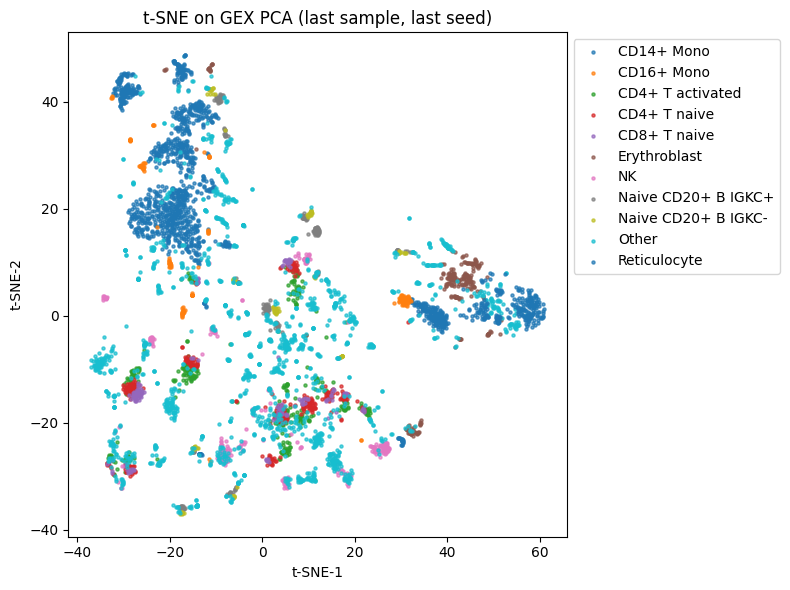

In [21]:
plt.figure(figsize=(8,6))
uniq, cnt = np.unique(labels, return_counts=True)
top = set(uniq[np.argsort(-cnt)[:10]])
labels2 = np.array([l if l in top else 'Other' for l in labels], dtype=object)

for lab in np.unique(labels2):
    m = (labels2 == lab)
    plt.scatter(X_tsne_list[-1][-1][-1][m,0], X_tsne_list[-1][-1][-1][m,1], s=5, alpha=0.7, label=lab)

plt.title('t-SNE on GEX PCA (last sample, last seed)')
plt.xlabel('t-SNE-1'); plt.ylabel('t-SNE-2')
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.tight_layout()
plt.show()
